In [1]:
!pip install yfinance

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM
import matplotlib.pyplot as plt

E:\conda\envs\project\lib\site-packages\sklearn\utils\fixes.py:28: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version  # type: ignore


In [3]:
stocks = ["AAPL","MSFT","GOOGL","AMZN","TSLA","META","NFLX","NVDA","TCS.NS","INFY.NS","RELIANCE.NS"]
data = {}
for stock in stocks:
    df = yf.download(stock, start="2025-01-01", end="2025-12-31")
    data[stock] = df[["Close"]]

C:\Users\DELL\AppData\Local\Temp\ipykernel_22636\1503621281.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\DELL\AppData\Local\Temp\ipykernel_22636\1503621281.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\DELL\AppData\Local\Temp\ipykernel_22636\1503621281.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock, start="2025-01-01", end="2025-12-31")
[*********************100%***********************]  1 of 1 completed
C:\Users\DELL\AppData\Local\Temp\ipykernel_22636\1503621281.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(stock,

In [4]:
def create_dataset(dataset, time_step=60):
    X, y = [], []
    for i in range(len(dataset)-time_step-1):
        X.append(dataset[i:(i+time_step), 0])
        y.append(dataset[i+time_step, 0])
    return np.array(X), np.array(y)

In [5]:
models = {}
scalers = {}
histories = {}

In [7]:
for stock in stocks:
    df = data[stock].values
    
    scaler = MinMaxScaler(feature_range=(0,1))
    df_scaled = scaler.fit_transform(df)
    
    training_size = int(len(df_scaled)*0.8)
    train_data = df_scaled[:training_size]
    test_data = df_scaled[training_size:]
    
    X_train, y_train = create_dataset(train_data)
    X_test, y_test = create_dataset(test_data)
    
    X_train = X_train.reshape(X_train.shape[0], X_train.shape[1], 1)
    
    if len(X_test) > 0:
        X_test = X_test.reshape(X_test.shape[0], X_test.shape[1], 1)
    else:
        X_test = np.empty((0,60,1))
        y_test = np.empty((0,))
    
    model = Sequential()
    model.add(LSTM(50, return_sequences=True, input_shape=(60,1)))
    model.add(LSTM(50))
    model.add(Dense(1))
    
    model.compile(loss='mean_squared_error', optimizer='adam')
    
    if len(X_test) > 0:
        history = model.fit(X_train, y_train, validation_data=(X_test, y_test), epochs=5, batch_size=32, verbose=1)
    else:
        history = model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=1)
    
    models[stock] = model
    scalers[stock] = scaler
    histories[stock] = history

E:\conda\envs\project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 9s 101ms/step - loss: 0.1396
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0246
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0208
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0130
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0160


E:\conda\envs\project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 94ms/step - loss: 0.3482
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0489
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0431
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 106ms/step - loss: 0.0109
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0192


E:\conda\envs\project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


...

Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 97ms/step - loss: 0.0608
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 107ms/step - loss: 0.0158
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0095
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0098
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0080


E:\conda\envs\project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 7s 95ms/step - loss: 0.0417
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0219
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - loss: 0.0097
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - loss: 0.0128
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0099


E:\conda\envs\project\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 8s 96ms/step - loss: 0.2427
Epoch 2/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0249
Epoch 3/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - loss: 0.0277
Epoch 4/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - loss: 0.0150
Epoch 5/5
5/5 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - loss: 0.0160


In [8]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import math

metrics = {}

for stock in stocks:
    df = data[stock].values
    scaler = scalers[stock]
    model = models[stock]
    
    df_scaled = scaler.transform(df)
    
    X, y = create_dataset(df_scaled)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    y_pred = model.predict(X, verbose=0)
    
    y_true = scaler.inverse_transform(y.reshape(-1,1))
    y_pred = scaler.inverse_transform(y_pred)
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = math.sqrt(mean_squared_error(y_true, y_pred))
    
    accuracy = 100 - (mae / np.mean(y_true)) * 100
    
    metrics[stock] = (mae, rmse, accuracy)

In [9]:
for stock in stocks:
    mae, rmse, acc = metrics[stock]
    print(stock)
    print("MAE:", mae)
    print("RMSE:", rmse)
    print("Accuracy:", acc)
    print("----------------------")

AAPL
MAE: 12.764449505095786
RMSE: 15.594303369523612
Accuracy: 94.48503086907964
----------------------
MSFT
MAE: 13.379194219061668
RMSE: 16.34582155024987
Accuracy: 97.21221085031232
----------------------
GOOGL
MAE: 13.817082019562417
RMSE: 18.52280411598446
Accuracy: 93.6851771238473
----------------------
AMZN
MAE: 7.169461270596119
RMSE: 9.680584292667541
Accuracy: 96.70729628439112
----------------------
TSLA
MAE: 25.849709612257936
RMSE: 32.698418215625395
Accuracy: 92.88915632509931
----------------------
META
MAE: 29.38203478874044
RMSE: 37.20152054173763
Accuracy: 95.65294920121129
----------------------
NFLX
MAE: 5.502942308466485
RMSE: 6.3669520647927484
Accuracy: 95.19569957330033
----------------------
NVDA
MAE: 9.02029471701764
RMSE: 10.976831262903897
Accuracy: 94.43857788734331
----------------------
TCS.NS
MAE: 73.45737591911767
RMSE: 96.09231562875226
Accuracy: 97.66869331197601
----------------------
INFY.NS
MAE: 42.503335065382686
RMSE: 52.57859448718378
Accuracy

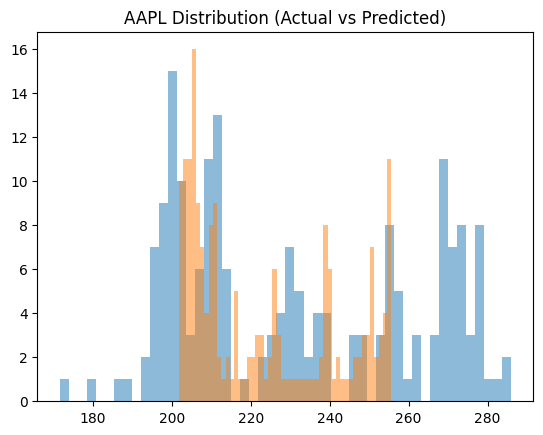

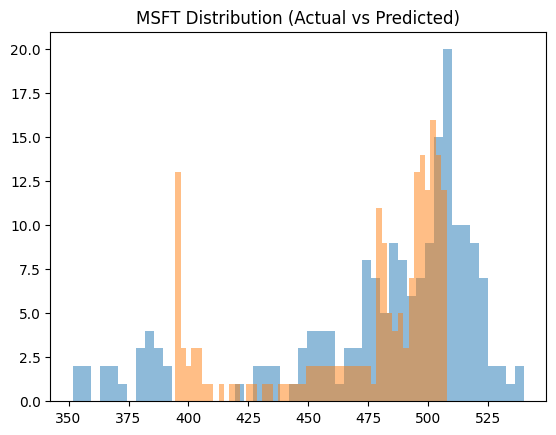

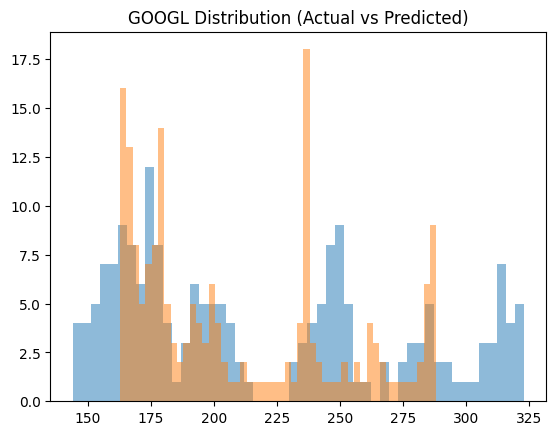

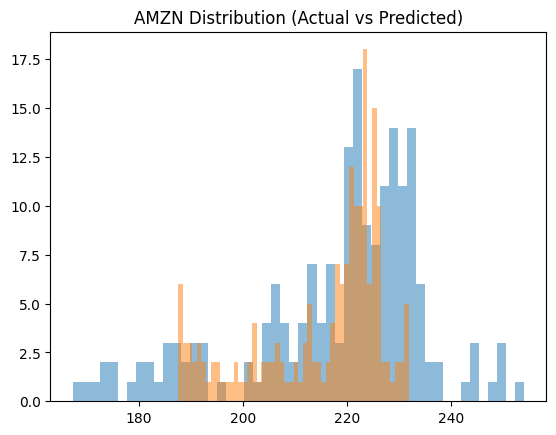

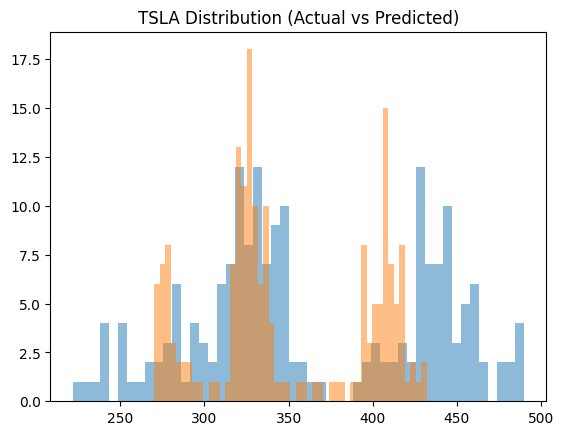

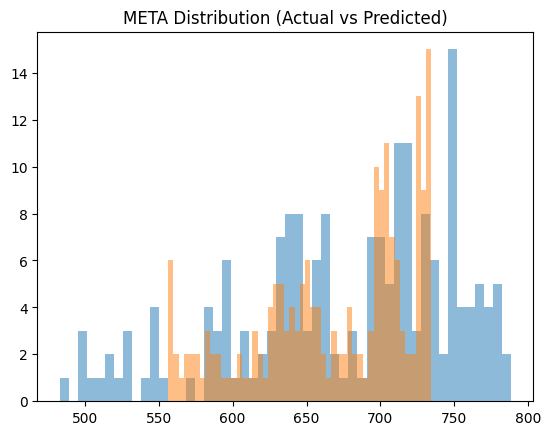

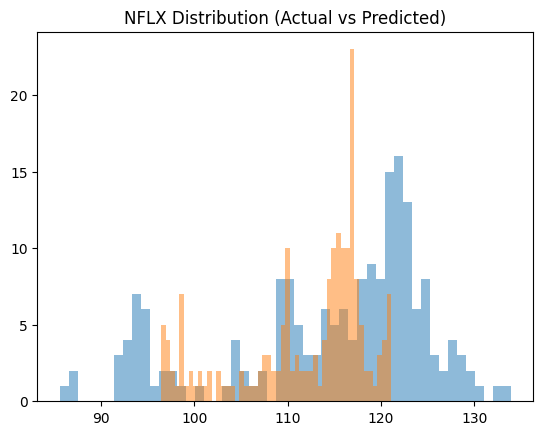

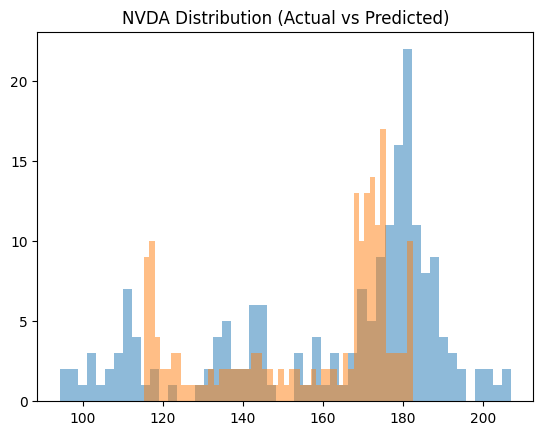

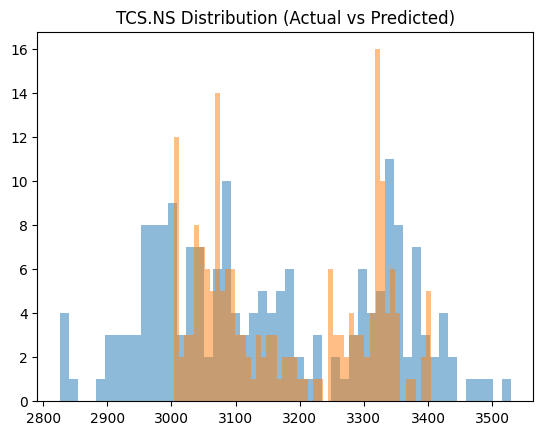

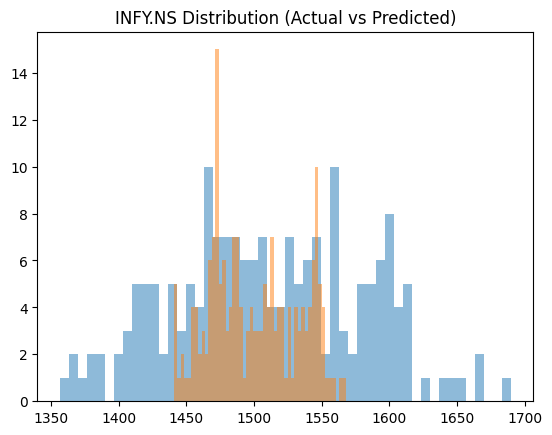

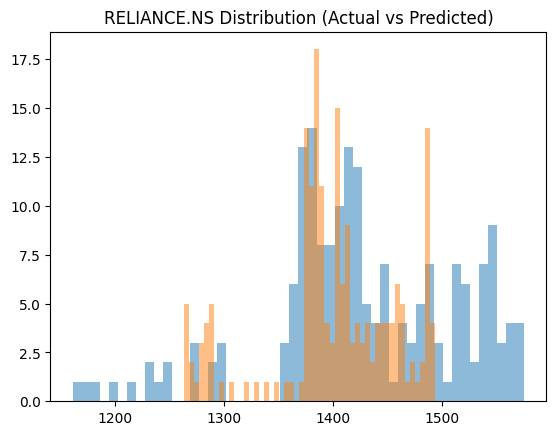

In [10]:
for stock in stocks:
    df = data[stock].values
    scaler = scalers[stock]
    model = models[stock]
    
    df_scaled = scaler.transform(df)
    
    X, y = create_dataset(df_scaled)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    y_pred = model.predict(X, verbose=0)
    
    y_true = scaler.inverse_transform(y.reshape(-1,1))
    y_pred = scaler.inverse_transform(y_pred)
    
    plt.figure()
    plt.hist(y_true.flatten(), bins=50, alpha=0.5)
    plt.hist(y_pred.flatten(), bins=50, alpha=0.5)
    plt.title(stock + " Distribution (Actual vs Predicted)")
    plt.show()

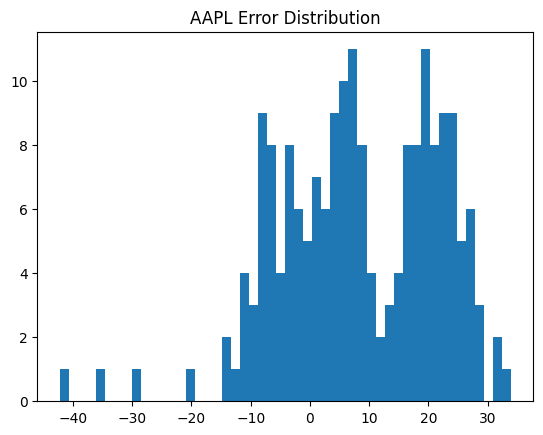

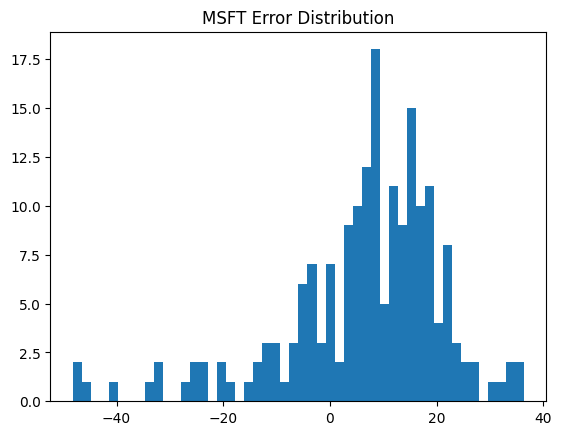

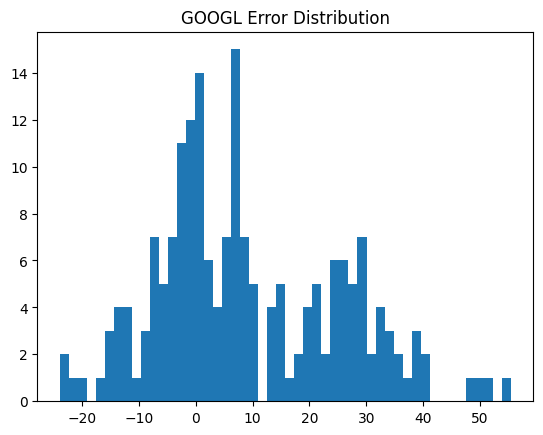

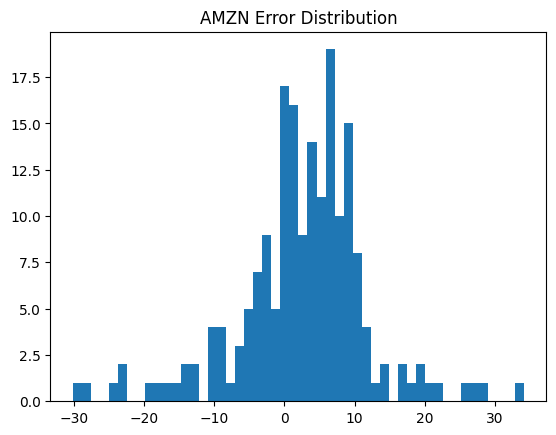

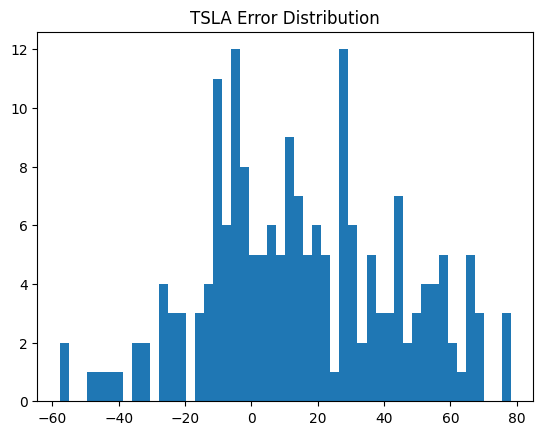

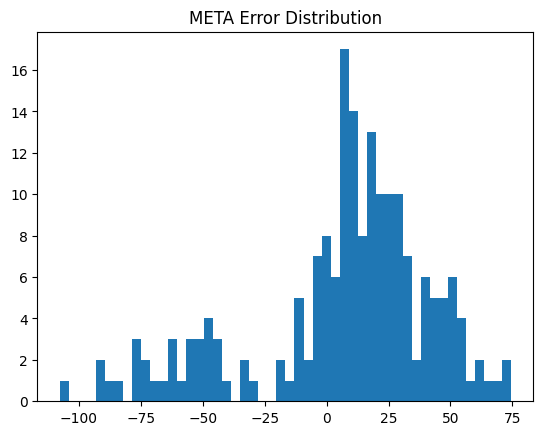

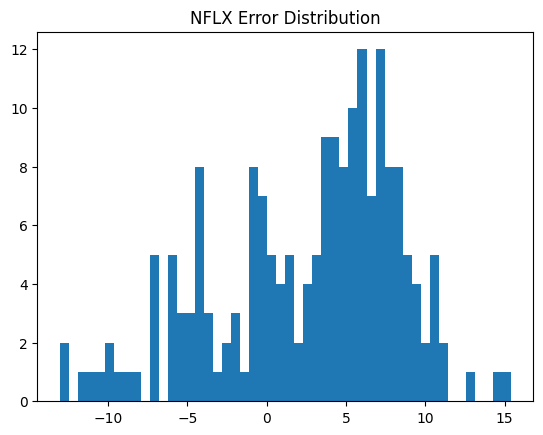

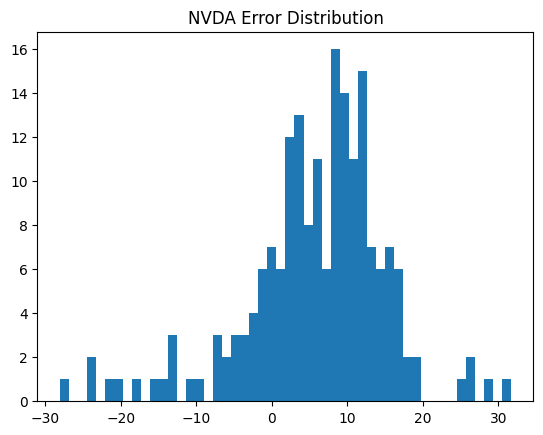

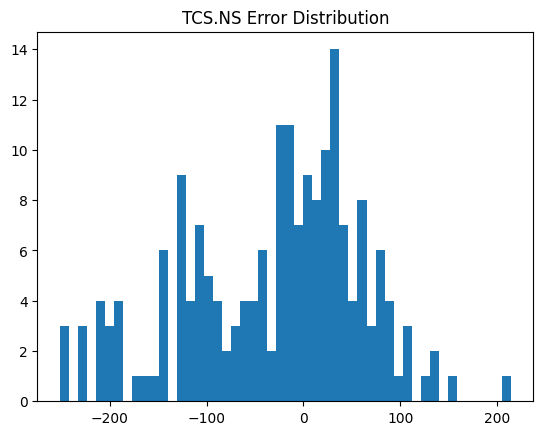

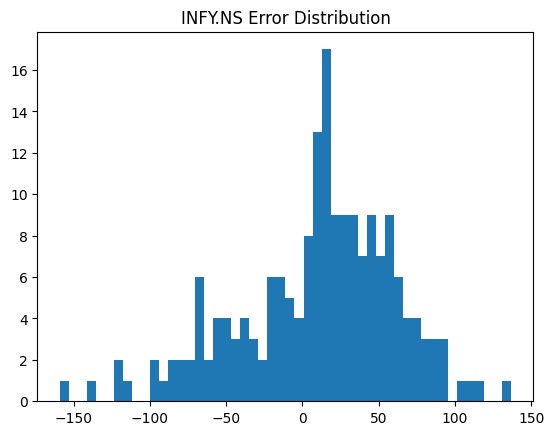

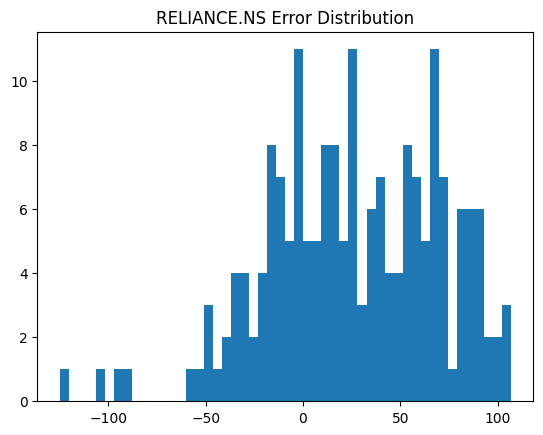

In [11]:
for stock in stocks:
    df = data[stock].values
    scaler = scalers[stock]
    model = models[stock]
    
    df_scaled = scaler.transform(df)
    
    X, y = create_dataset(df_scaled)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    y_pred = model.predict(X, verbose=0)
    
    y_true = scaler.inverse_transform(y.reshape(-1,1))
    y_pred = scaler.inverse_transform(y_pred)
    
    error = y_true - y_pred
    
    plt.figure()
    plt.hist(error.flatten(), bins=50)
    plt.title(stock + " Error Distribution")
    plt.show()

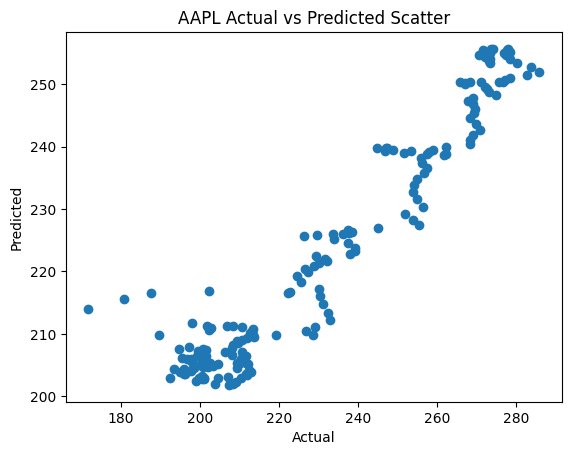

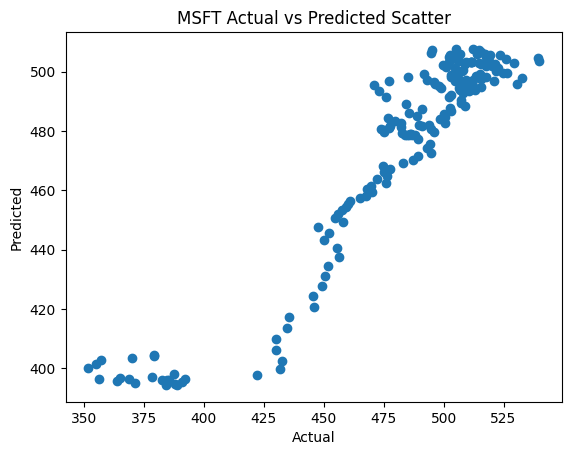

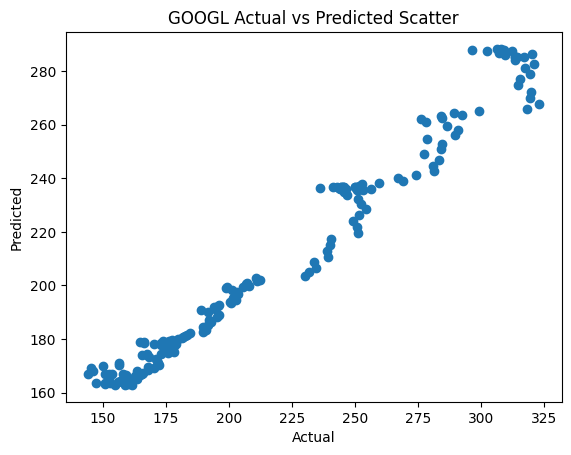

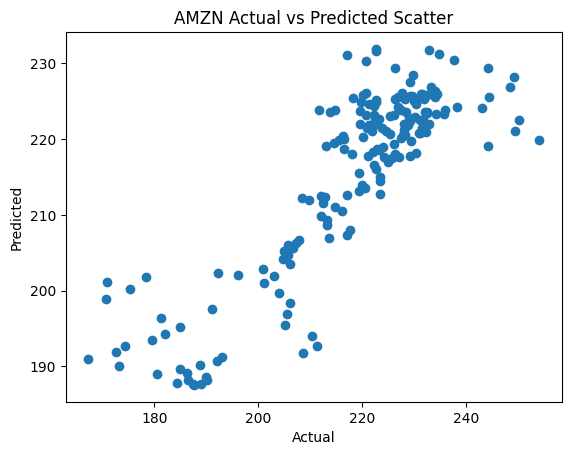

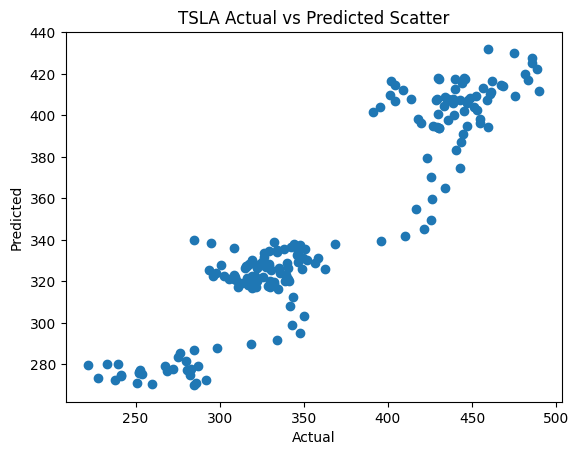

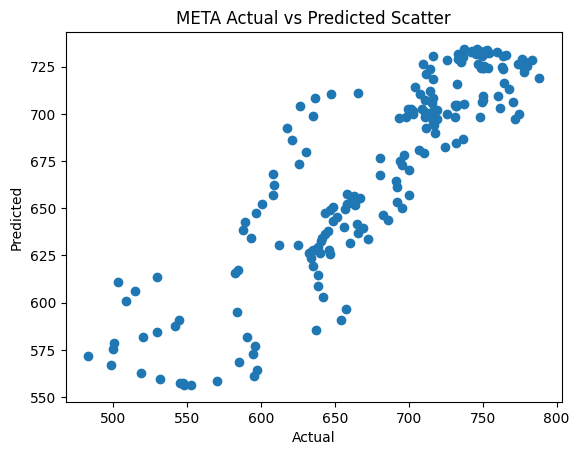

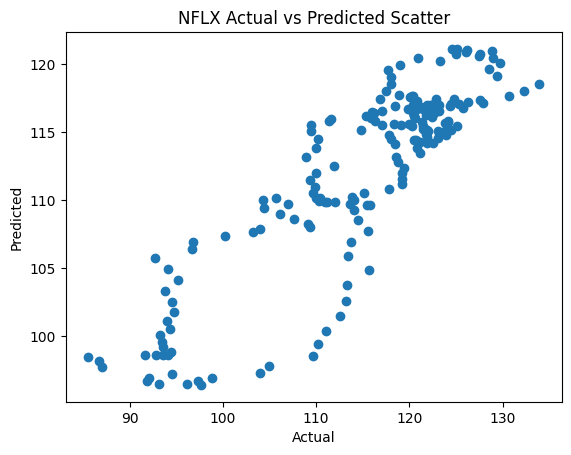

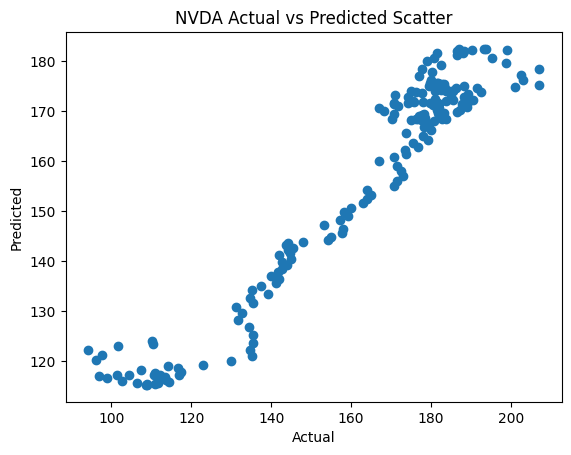

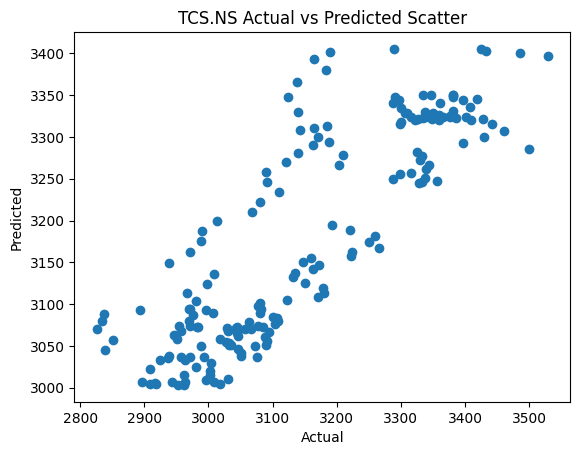

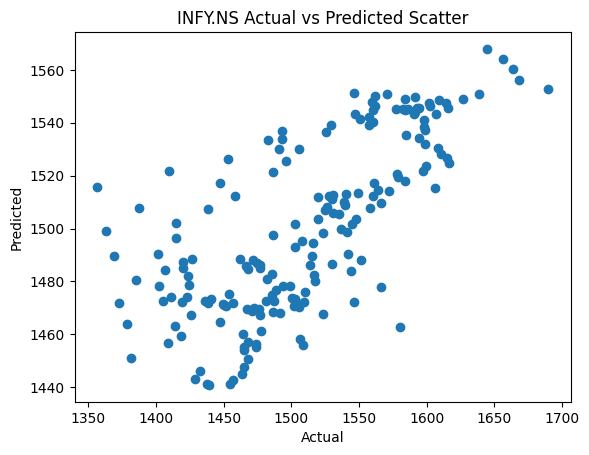

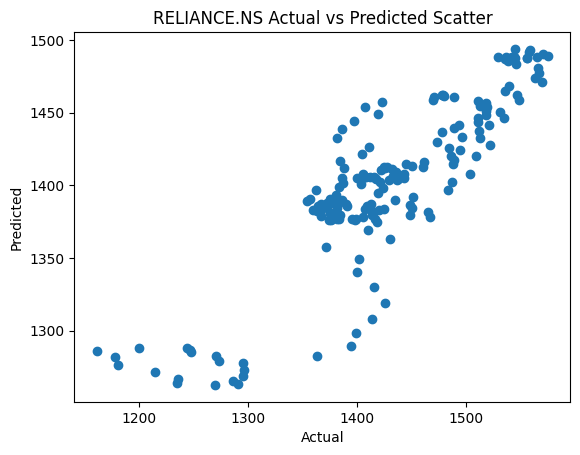

In [12]:
for stock in stocks:
    df = data[stock].values
    scaler = scalers[stock]
    model = models[stock]
    
    df_scaled = scaler.transform(df)
    
    X, y = create_dataset(df_scaled)
    X = X.reshape(X.shape[0], X.shape[1], 1)
    
    y_pred = model.predict(X, verbose=0)
    
    y_true = scaler.inverse_transform(y.reshape(-1,1))
    y_pred = scaler.inverse_transform(y_pred)
    
    plt.figure()
    plt.scatter(y_true, y_pred)
    plt.title(stock + " Actual vs Predicted Scatter")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()

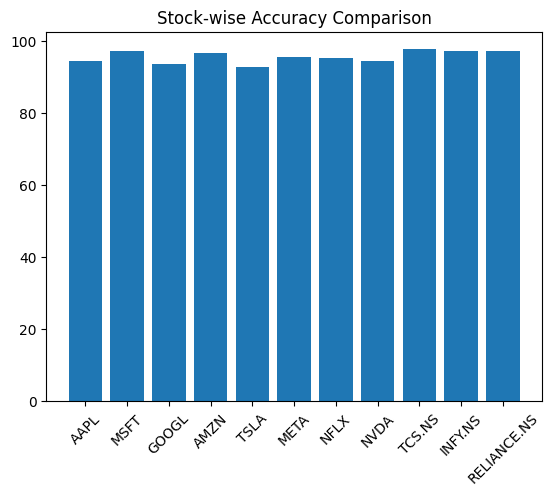

In [13]:
stock_names = []
accuracies = []

for stock in stocks:
    mae, rmse, acc = metrics[stock]
    stock_names.append(stock)
    accuracies.append(acc)

plt.figure()
plt.bar(stock_names, accuracies)
plt.xticks(rotation=45)
plt.title("Stock-wise Accuracy Comparison")
plt.show()

In [16]:
import os
import joblib
os.makedirs("models", exist_ok=True)
os.makedirs("scalers", exist_ok=True)

for stock in stocks:
    models[stock].save(f"models/{stock}.h5")
    joblib.dump(scalers[stock], f"scalers/{stock}_scaler.pkl")